In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')


In [2]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

In [3]:
import pandas as pd
from sklearn.datasets import load_iris

# 1. Load the raw Iris dataset
iris_bunch = load_iris()

# 2. Convert features to a Pandas DataFrame
df = pd.DataFrame(data=iris_bunch.data, columns=iris_bunch.feature_names)

# 3. Add the target column (the flower species numbers: 0, 1, or 2)
df['target'] = iris_bunch.target

# 4. Map the numbers to actual species names (Setosa, Versicolor, Virginica)
df['species'] = df['target'].map(lambda x: iris_bunch.target_names[x])

# 5. Display the first 5 rows of data
print("--- Iris Dataset Sample ---")
df.head()

--- Iris Dataset Sample ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


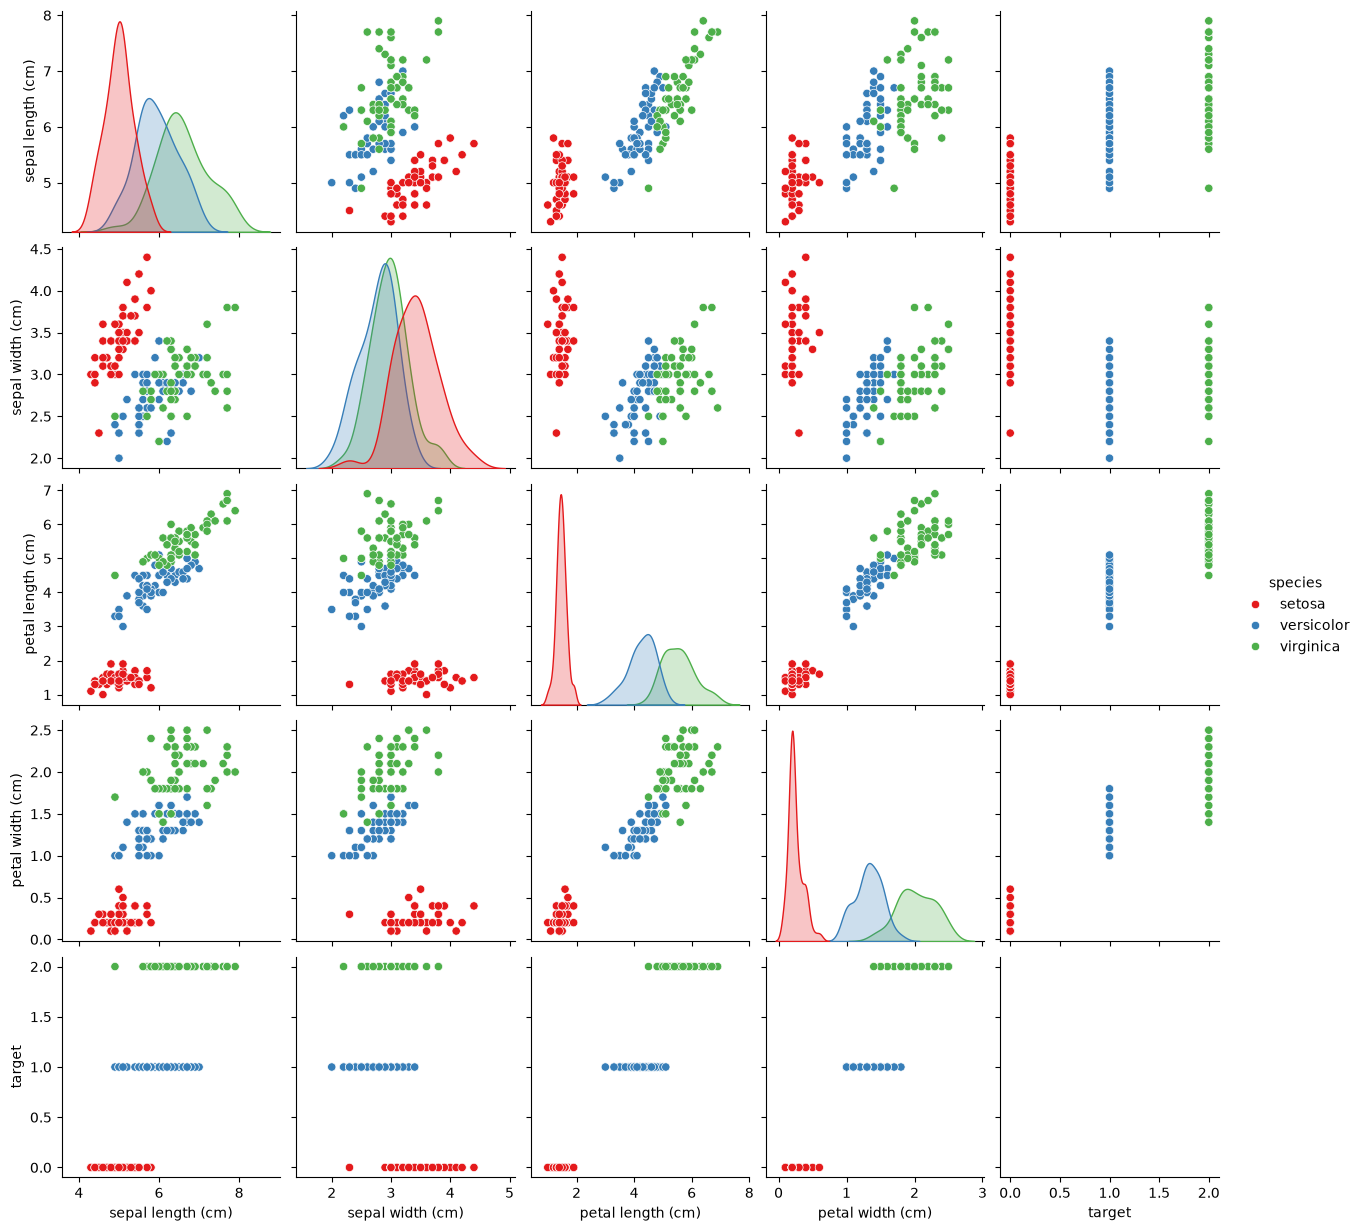

In [4]:
sns.pairplot(df,hue='species',palette='Set1')

In [5]:
X=df.drop(['target','species'],axis=1)
Y=df['target']
Y.value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [16]:
X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled,Y,test_size=0.2,random_state=42)
X_train

array([[-1.50652052e+00,  1.24920112e+00, -1.56757623e+00,
        -1.31544430e+00],
       [-1.73673948e-01,  3.09077525e+00, -1.28338910e+00,
        -1.05217993e+00],
       [ 1.03800476e+00,  9.82172869e-02,  3.64896281e-01,
         2.64141916e-01],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
        -1.31544430e+00],
       [-1.74885626e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [ 5.53333275e-01, -1.28296331e+00,  7.05920842e-01,
         9.22302838e-01],
       [ 6.74501145e-01,  3.28414053e-01,  4.21733708e-01,
         3.95774101e-01],
       [-7.79513300e-01,  1.01900435e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-7.79513300e-01,  2.40018495e+00, -1.28338910e+00,
        -1.44707648e+00],
       [-5.25060772e-02, -8.22569778e-01,  7.62758269e-01,
         9.22302838e-01],
       [ 1.89829664e-01,  7.88807586e-01,  4.21733708e-01,
      

In [14]:
per=Perceptron(max_iter=1000,random_state=42)
per.fit(X_train,y_train)
y_pred=per.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))    

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



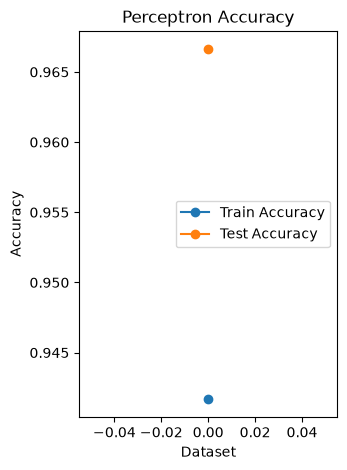

In [15]:
# Plot training & validation accuracy values of perceptron
plt.subplot(1, 2, 1)
plt.plot(per.score(X_train, y_train), label='Train Accuracy', marker='o')
plt.plot(per.score(X_test, y_test), label='Test Accuracy', marker='o')
plt.title('Perceptron Accuracy')
plt.xlabel('Dataset')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


Artificial Neural Network

In [8]:
# one hot encoding the target variable
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)
y_train_cat

array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1

In [9]:
model = Sequential(
    [
        Dense(16, activation='relu', input_shape=(4,)),
        Dense(8, activation='relu'),
        Dense(3, activation='softmax')
    ]
)

In [10]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(
    X_train, y_train_cat, 
    epochs=100, 
    batch_size=10,
    validation_data=(X_test, y_test_cat),
    verbose=1
    )

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3417 - loss: 1.0121 - val_accuracy: 0.4000 - val_loss: 0.8509
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3417 - loss: 0.9383 - val_accuracy: 0.4667 - val_loss: 0.7870
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5250 - loss: 0.8766 - val_accuracy: 0.7667 - val_loss: 0.7365
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6750 - loss: 0.8290 - val_accuracy: 0.7667 - val_loss: 0.6952
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6750 - loss: 0.7849 - val_accuracy: 0.7667 - val_loss: 0.6579
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6750 - loss: 0.7455 - val_accuracy: 0.7667 - val_loss: 0.6191
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6750 - loss: 0.7058 - val_accuracy: 0.7667 - val_loss: 0.5797
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6833 - loss: 0.6653 - val_accuracy: 0.8000 

In [12]:
loss, accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

Test Loss: 0.0545, Test Accuracy: 1.0000


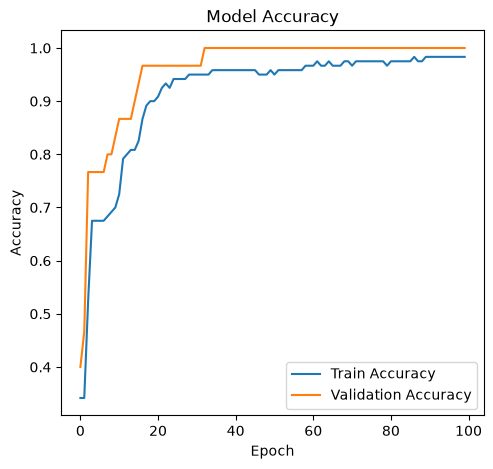

In [11]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()



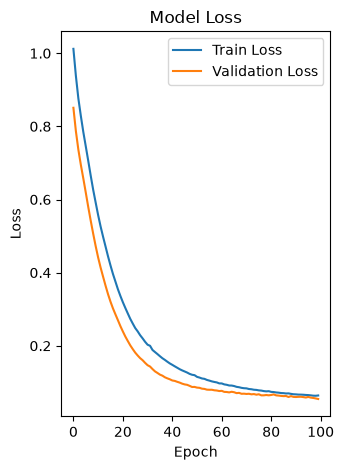

In [13]:
# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
import numpy as np

sample = np.array([[5.1, 3.5, 1.4, 0.2]])
scaler = StandardScaler().fit(X)         # fit on original X to match training scaling
sample_scaled = scaler.transform(sample)
probs = model.predict(sample_scaled)
pred_class = np.argmax(probs, axis=1)[0]
print("Probs:", probs, "Predicted class:", pred_class, "Species:", iris_bunch.target_names[pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Probs: [[9.998135e-01 1.229197e-04 6.369241e-05]] Predicted class: 0 Species: setosa
